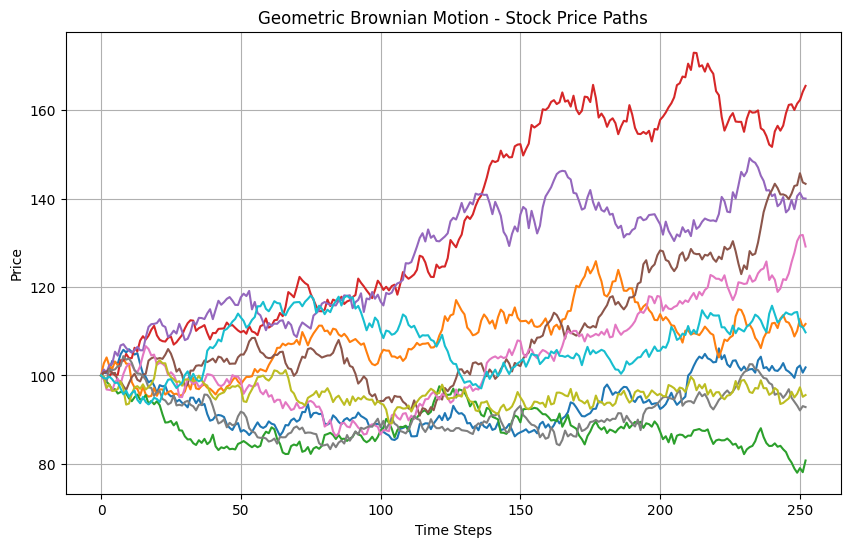

模拟平均价格: 117.05
模拟标准差: 25.29
理论期望价格: 105.13


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 几何布朗运动模拟函数
def simulate_gbm(S0, mu, sigma, T, n_steps, n_sims):
    dt = T / n_steps
    dW = np.random.normal(0, np.sqrt(dt), size=(n_sims, n_steps))
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * dW
    log_cumsum = np.cumsum(log_returns, axis=1)
    S = S0 * np.exp(log_cumsum)
    S = np.hstack([S0 * np.ones((n_sims, 1)), S])
    return S

# 参数设置
S0 = 100
mu = 0.05
sigma = 0.2
T = 1
n_steps = 252
n_sims = 10

# 模拟
np.random.seed(42)
paths = simulate_gbm(S0, mu, sigma, T, n_steps, n_sims)

# 画图
plt.figure(figsize=(10, 6))
for i in range(n_sims):
    plt.plot(paths[i])
plt.title('Geometric Brownian Motion - Stock Price Paths')
plt.xlabel('Time Steps')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# 统计
final_prices = paths[:, -1]
print(f'模拟平均价格: {final_prices.mean():.2f}')
print(f'模拟标准差: {final_prices.std():.2f}')
print(f'理论期望价格: {S0 * np.exp(mu * T):.2f}')